<a href="https://colab.research.google.com/github/JV005/Vanilla_agent/blob/main/Langgraph_Agent_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langgraph langchain langchain-openai tavily-python graphviz matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 839.1 kB/s eta 0:00:00


In [68]:
from getpass import getpass
import os
os.environ["OPENAI_API_KEY"]= getpass("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]= getpass("TAVILY_API_KEY")

OPENAI_API_KEY··········
TAVILY_API_KEY··········


In [69]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")

In [70]:
from tavily import TavilyClient
from langchain_core.tools import tool


@tool
def web_search(q):
    """
    Performs a web search using the Tavily API.
    This function initializes a Tavily client with an API key and performs a search
    query using their search engine. Tavily specializes in providing AI optimized
    search results with high accuracy and relevance.

    Args:
        q (str): The search query string to be processed by the Tavily's search engine.
    Returns:
        dict: A dictionary containing the search results from Tavily. The results typically include
            - title: The title of the search result.
            - url: The URL of the search result.
            - content: A brief description or snippet of the search result.
            - Score: Relevance score of the result
            - published_date: The date when the content was published.( if available)
    Example:
        >>> results = web_search("artificial intelligence trends 2026
        >>> print(results)

    """
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    results = client.search(q)
    return results


@tool
def calculator(math_expression):
    """
    Evaluates a athematical expression provided as a string.

    WARNING: Using Eval on arbitrary input is dangerous as it can execute malicious code.
    This function should only be usedd with trusted input in  acontrolled environment.
    Args:
        X (str): A string containing a mathematical expression (e.g., "2 + 2*, "5*3").

    Returns:
        The numerical result of evaluating the expression
    Examples:
        >>> calculator("2 + 2")
        4
        >>> calculator("5 * 3")
        15
        """
    try:
        result = eval(math_expression)
        return result
    except Exception as e:
        return f"Error evaluating expression: {e}"

In [71]:
tools = [web_search, calculator]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools=llm.bind_tools(tools)

In [79]:
system_msg="""
## You are a highly capable research assistant and finance writer. Your primary role is to execute a multistep research process to produce well-researched reports based on user provided topics and instructions.
###approach and workflow:
-Plan Formation - Before executing any research, break down the task into logical steps and determine the bext strategy.
-Information Gathering - Use available toold (e.g. weeb_search) to find relevant andd high quality information.
- Summarization and Extraction - Condense key insights from gathered sources while maintaining accuracy and relevance.
- Analysis and Iteration - Critically assess summaries, identify gaps and areas needing deeoer exploration and refine search queries accordingly.
-  Output Generation -  Present findings in a structured, coherent and well organized format, suitable for finance professionals and decision makers.

### Guiding Principles:
-Systematic Execution - Always decise a plan before starting any task and adjust based on findings.
- iterative Refinement - Research is a process; reevalueate and improve each step.
- Actionable Insights- focus aon delivering practical and relevant conclusions.
- Accuracy and Reliability - Prioritize credible source and fact check as needed.
"""

In [80]:
from typing import Literal
from langgraph.graph import MessagesState, END
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage

def llm_call(state:MessagesState):
  """LLM decides whether to call a tool or not"""

  return{
      "messages":[llm_with_tools.invoke(
        [
            SystemMessage(content=system_msg
            )
        ]
        + state["messages"]
        )
      ]
  }


def tool_node(state: dict):
  """performs the tool call"""
  result=[]
  for tool_call in state["messages"][-1].tool_calls:
    tool= tools_by_name[tool_call["name"]]
    observation = tool.invoke(tool_call["args"])
    result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
  return {"messages": result}




In [81]:
def should_continue(state:MessagesState) -> Literal["environment", END]:
  """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""
  messages=state["messages"]
  last_message= messages[-1]

  #if the LLm makes a tool call, then perform an action
  if last_message.tool_calls:
    return "Action"

  #Otherwise we stop (reply to the user)
  return END

In [74]:
from langgraph.graph import StateGraph, START

#build agent
agent_builder = StateGraph(MessagesState)

#Add Nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

#add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        #Name returned by should_continue : Name of next node to visit
        "Action": "environment",
        END : END,
    },
)
agent_builder.add_edge("environment","llm_call")

agent=agent_builder.compile()

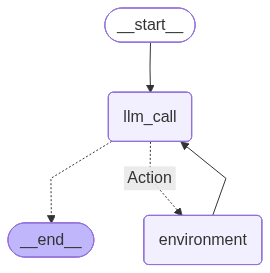

In [75]:
# Visualize Agent

from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [83]:
task = """
## Ressearch and summarize the most important U.S economic indicators released in February and March 2025 in a 500-word report.
Include:
- Recently reported figures for key indicators and the latest forecasts for upcoming releases.
- Analyze: the significance of these indicators and their impact on both the U.S and the global economy
- Focus on: Trends, surprises and econimic implications

Ensure the summary is data-driven.
"""

In [84]:
messages =[HumanMessage(content=task)]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================


## Ressearch and summarize the most important U.S economic indicators released in February and March 2025 in a 500-word report.
Include:
- Recently reported figures for key indicators and the latest forecasts for upcoming releases.
- Analyze: the significance of these indicators and their impact on both the U.S and the global economy
- Focus on: Trends, surprises and econimic implications

Ensure the summary is data-driven.

================================== Ai Message ==================================
Tool Calls:
  web_search (call_KdmPTM2tb9133d1XblQXD0hD)
 Call ID: call_KdmPTM2tb9133d1XblQXD0hD
  Args:
    q: U.S economic indicators February 2025 report
  web_search (call_Dn08h8ZJgxcQuvoeJRdMmEuN)
 Call ID: call_Dn08h8ZJgxcQuvoeJRdMmEuN
  Args:
    q: U.S economic indicators March 2025 report
  web_search (call_DFaFe2puHSMYF5uPN2BDotIn)
 Call ID: call_DFaFe2puHSMYF5uPN2BDotIn
  Args:
    q: U.S econ